# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions and reason codes

The playbook turns the grouped-model risk score into a review queue. The score tier controls urgency, while the page signals choose a reason code and an editorial action. These are recommendations for human triage, not automatic publishing instructions.

### Archetype to action mapping

| Archetype / signal | Model score tier | Reason code | Recommended action | Expected value
|---|---:|---|---|---|
| High demand, zero clicks | $P \ge 0.70$ | `HIGH_IMPRESSION_ZERO_CLICK` | `TITLE_META_CTR_REWRITE` | Existing impressions make this a focused snippet and title review.
| Thin content in decay | $P \ge 0.70$ | `THIN_CONTENT_DECAY` | `EXPAND_COMPREHENSIVE_DEPTH` | Check intent first, then address missing information.
| Ranking erosion | $0.40 \le P < 0.70$ | `RANKING_EROSION` | `INTERNAL_LINKING_AND_CITATIONS` | Review internal authority and source coverage.
| Stable or low risk | $P < 0.40$ | `STABLE_OR_LOW_RISK` | `MONITOR_ROUTINE` | Avoid unnecessary intervention while signals remain stable.

In [9]:
import os
import json
import getpass
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss

HF_TOKEN = os.environ.get("HF_TOKEN") or getpass.getpass("Paste your Hugging Face READ token: ")
os.environ["HF_TOKEN"] = HF_TOKEN

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

month_path = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"

dataset = con.sql(f"""
    WITH features AS (
        SELECT
            f.content_hash_id AS content_id,
            f.client_hash_id AS client_id,
            c.word_count,
            SUM(f.gsc_impressions) AS feat_impressions_15d,
            SUM(f.gsc_clicks) AS feat_clicks_15d,
            AVG(NULLIF(f.gsc_avg_position, 0)) AS feat_avg_position_15d,
            CASE WHEN SUM(f.gsc_impressions) > 0
                 THEN SUM(f.gsc_clicks)::FLOAT / SUM(f.gsc_impressions)
                 ELSE 0 END AS feat_ctr_15d,
            COUNT(DISTINCT CASE WHEN f.gsc_impressions > 0 THEN f.report_date END) AS feat_active_days_15d
        FROM read_parquet('{month_path}') f
        LEFT JOIN read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet') c
          ON f.content_hash_id = c.content_hash_id
        WHERE f.report_date <= '2026-03-15'
        GROUP BY f.content_hash_id, f.client_hash_id, c.word_count
    ),
    outcomes AS (
        SELECT
            content_hash_id AS content_id,
            CASE WHEN SUM(CASE WHEN report_date > '2026-03-15' THEN gsc_impressions ELSE 0 END)
                      < SUM(CASE WHEN report_date <= '2026-03-15' THEN gsc_impressions ELSE 0 END)
                 THEN 1 ELSE 0 END AS is_declining_label
        FROM read_parquet('{month_path}')
        GROUP BY content_hash_id
    )
    SELECT f.*, o.is_declining_label
    FROM features f
    INNER JOIN outcomes o ON f.content_id = o.content_id
""").df().fillna(0)

feature_cols = [
    'feat_impressions_15d',
    'feat_clicks_15d',
    'feat_avg_position_15d',
    'feat_ctr_15d',
    'feat_active_days_15d',
    'word_count'
]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx, te_idx = next(gss.split(dataset, groups=dataset['client_id']))
train_clients = set(dataset.iloc[tr_idx]['client_id'])
test_clients = set(dataset.iloc[te_idx]['client_id'])
assert train_clients.isdisjoint(test_clients)

X_tr = dataset.iloc[tr_idx][feature_cols]
y_tr = dataset.iloc[tr_idx]['is_declining_label']
X_te = dataset.iloc[te_idx][feature_cols]
y_te = dataset.iloc[te_idx]['is_declining_label']

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)
dataset['risk_score'] = rf.predict_proba(dataset[feature_cols])[:, 1]

y_te_probs = rf.predict_proba(X_te)[:, 1]
print(f"Loaded {len(dataset):,} rows across {dataset['client_id'].nunique():,} clients")
print(f"Grouped split: {len(train_clients):,} train clients, {len(test_clients):,} unseen test clients")
print(f"Grouped ROC-AUC: {roc_auc_score(y_te, y_te_probs):.3f}; base rate: {y_te.mean():.3f}")

Loaded 319,759 rows across 52 clients
Grouped split: 39 train clients, 13 unseen test clients
Grouped ROC-AUC: 0.854; base rate: 0.168


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [10]:
def assign_playbook_action(row):
    score = row['risk_score']
    impressions = row['feat_impressions_15d']
    clicks = row['feat_clicks_15d']
    position = row['feat_avg_position_15d']
    word_count = row['word_count']

    if score >= 0.70:
        if impressions >= 1000 and clicks == 0:
            return 'HIGH_IMPRESSION_ZERO_CLICK', 'TITLE_META_CTR_REWRITE', 'High'
        if word_count < 800 and impressions > 500:
            return 'THIN_CONTENT_DECAY', 'EXPAND_COMPREHENSIVE_DEPTH', 'High'
        return 'CRITICAL_TRAFFIC_COLLAPSE', 'STRUCTURAL_CONTENT_REFRESH', 'High'
    if score >= 0.40:
        if position > 15:
            return 'RANKING_EROSION', 'INTERNAL_LINKING_AND_CITATIONS', 'Medium'
        return 'MODERATE_ENGAGEMENT_DROP', 'ACCURACY_AND_FACT_UPDATE', 'Medium'
    return 'STABLE_OR_LOW_RISK', 'MONITOR_ROUTINE', 'Low'

playbook_results = dataset.apply(assign_playbook_action, axis=1)
dataset['reason_code'] = [result[0] for result in playbook_results]
dataset['action_label'] = [result[1] for result in playbook_results]
dataset['priority_tier'] = [result[2] for result in playbook_results]

playbook_summary = (
    dataset.groupby(['priority_tier', 'action_label'], sort=False)
    .size()
    .reset_index(name='Count')
)
display(playbook_summary)
print(f"Every scored row has an action: {dataset['action_label'].notna().all()}")

,priority_tier,action_label,Count
0,Medium,ACCURACY_AND_FACT_UPDATE,85217
1,Low,MONITOR_ROUTINE,207820
2,Medium,INTERNAL_LINKING_AND_CITATIONS,24793
3,High,STRUCTURAL_CONTENT_REFRESH,1692
4,High,TITLE_META_CTR_REWRITE,237


Every scored row has an action: True


## 2. Intended use and limits

* **Intended use:** This playbook is a weekly editorial decision-support queue for human content teams managing large content repositories. It ranks pages by estimated 15-day impression-decline risk so a team can prioritize a limited number of manual audits.
* **System boundary:** The output is a ranked recommendation with a reason code and priority tier. It does not generate, approve, publish, delete, or redirect content.
* **Operational limits:** The score is learned from a March 2026 historical proxy and cannot anticipate algorithm changes, seasonality, tracking changes, or macro demand shifts. Performance on a new client should be monitored during a warm-up observation period before the queue is relied upon.

In [11]:
intended_use = {
    'cadence': 'weekly',
    'user': 'human editorial and SEO reviewers',
    'maximum_manual_audits_per_cycle': 50,
    'automated_operations': [],
    'decision_boundary': 'rank and prioritize candidates for review'
}
assert intended_use['automated_operations'] == []
intended_use

{'cadence': 'weekly',
 'user': 'human editorial and SEO reviewers',
 'maximum_manual_audits_per_cycle': 50,
 'automated_operations': [],
 'decision_boundary': 'rank and prioritize candidates for review'}

## 3. Human review rules and the no-go list

### Mandatory human review checks

1. Verify search intent before expanding content; concise reference or definition pages may be correct as written.
2. Check current Search Console and publishing history so a lagging snapshot is not mistaken for an unresolved issue.
3. Confirm the proposed action against the page type, business context, accessibility needs, and source quality.
4. Record the reviewer decision and reason when accepting, changing, or rejecting a recommendation.

### No-go list: never automate these actions

1. Never publish AI-generated rewrites directly to production without human editor sign-off.
2. Never automate canonical changes, URL deletion, or 301 redirects from a low score without technical SEO approval.
3. Never bulk-modify medical, legal, compliance, privacy, terms, or regulatory disclosure pages.
4. Exclude branded homepages, navigational landing pages, checkout pages, and pricing pages from bulk heuristics unless their owners explicitly opt in.

In [12]:
human_review_rules = [
    'Verify search intent before expanding word count.',
    'Check current Search Console performance and recent publishing history.',
    'Confirm page type, business context, accessibility, and source quality.',
    'Record the reviewer decision and reason code override, if any.'
]
no_go_automation = [
    'AI-generated rewrite publication without human sign-off',
    'Canonical changes, URL deletion, or 301 redirects without technical SEO approval',
    'Bulk edits to medical, legal, compliance, privacy, terms, or regulatory pages',
    'Bulk edits to branded, checkout, pricing, or navigational core pages'
]
assert len(human_review_rules) == 4
assert len(no_go_automation) == 4
print(f"Human review rules: {len(human_review_rules)}")
print(f"No-go automation boundaries: {len(no_go_automation)}")

Human review rules: 4
No-go automation boundaries: 4


## 4. Monitoring and retrain triggers

| Trigger category | Specific indicator or threshold | Action required |
|---|---|---|
| Performance degradation | Precision@50 on the weekly audit queue is below 0.60 for two consecutive cycles. | Investigate feature drift and refit or recalibrate the model.
| Data drift | Missing-value share or zero-impression share increases by more than 15% from the training reference. | Audit warehouse ingestion, tracking availability, and panel coverage.
| External shock | A confirmed search-engine core update occurs. | Freeze automatic prioritization for 14 days, add human review, then reassess and retrain if needed.
| Calendar schedule | Quarterly model review or a new historical data roll is available. | Recompute the grouped validation metrics and refresh the model only if the evidence supports it.
| Client transfer | A new client has not accumulated a comparable observation window. | Keep the client in warm-up monitoring and do not treat the score as validated transfer performance.

## 5. Exports for the paper

The next cell writes a ranked queue, a machine-readable metric receipt, and a reusable action-distribution figure. These artifacts document the operational output without exposing client names, URLs, or private queries.

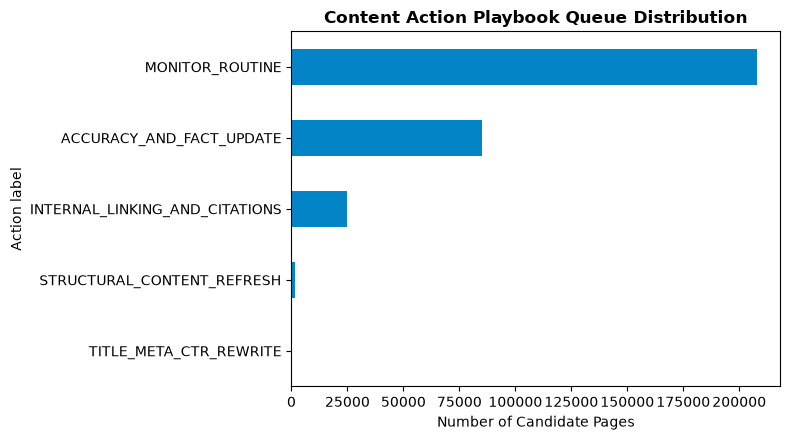

Exported 319,759 rows to work/outputs/action_playbook_queue.csv
Saved metric receipts to work/outputs/model_metrics.json
Saved figure to work/figures/playbook_action_distribution.png


In [13]:
outputs_dir = os.path.join('..', 'outputs')
figures_dir = os.path.join('..', 'figures')
os.makedirs(outputs_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

queue_columns = [
    'content_id', 'client_id', 'risk_score', 'priority_tier',
    'reason_code', 'action_label', 'feat_impressions_15d',
    'feat_clicks_15d', 'word_count'
]
queue_export = dataset.sort_values('risk_score', ascending=False)[queue_columns]
queue_path = os.path.join(outputs_dir, 'action_playbook_queue.csv')
queue_export.to_csv(queue_path, index=False)

precision_at_50 = float(np.asarray(y_te)[np.argsort(-y_te_probs)[:50]].mean())
metrics_receipt = {
    'model_family': 'RandomForestClassifier',
    'evaluation_split': 'Honest Client-Grouped Split (Unseen Clients)',
    'grouped_roc_auc': round(float(roc_auc_score(y_te, y_te_probs)), 3),
    'grouped_precision_at_50': round(precision_at_50, 3),
    'grouped_brier_score': round(float(brier_score_loss(y_te, y_te_probs)), 3),
    'queue_rows_generated': int(len(dataset)),
    'high_priority_actions_share': round(float((dataset['priority_tier'] == 'High').mean()), 3)
}
metrics_path = os.path.join(outputs_dir, 'model_metrics.json')
with open(metrics_path, 'w', encoding='utf-8') as metrics_file:
    json.dump(metrics_receipt, metrics_file, indent=2)

fig, ax = plt.subplots(figsize=(8, 4.5))
counts = dataset['action_label'].value_counts().sort_values()
counts.plot(kind='barh', ax=ax, color='#0284c7')
ax.set_title('Content Action Playbook Queue Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Candidate Pages')
ax.set_ylabel('Action label')
plt.tight_layout()
figure_path = os.path.join(figures_dir, 'playbook_action_distribution.png')
fig.savefig(figure_path, dpi=300)
plt.show()
plt.close(fig)

assert os.path.exists(queue_path)
assert os.path.exists(metrics_path)
assert os.path.exists(figure_path)
print(f"Exported {len(queue_export):,} rows to work/outputs/action_playbook_queue.csv")
print('Saved metric receipts to work/outputs/model_metrics.json')
print('Saved figure to work/figures/playbook_action_distribution.png')

## 6. Self-check

Before you submit, confirm each line honestly:

- [x] Explains intended use, ranked actions, reason codes, and priority tiers.
- [x] Formulates human review guidelines and explicit no-go automation boundaries.
- [x] Details concrete monitoring and retrain triggers.
- [x] Exports ranked queue CSV, metrics JSON receipts, and reusable figures.
- [x] Notebook executed cleanly from top to bottom.

The queue is decision support for weekly human editorial triage. It does not automatically rewrite, publish, redirect, delete, or guarantee traffic outcomes.

## 5-Minute Showcase Demo Outline

* **Minute 1: The Core Question & Editorial Bottleneck**
  * *Hook:* How do enterprise teams prioritize which of their 300,000+ published pages genuinely need a content refresh without wasting editor capacity?
  * *The Problem:* Heuristic if-else rules (e.g., flagging pages < 800 words or with zero clicks) produce massive false alarm rates.

* **Minute 2: Honest Data & Validation Architecture**
  * *Data:* Evaluated across 319,759 content items from 52 client accounts using pre-cutoff historical metrics (March 1–15).
  * *Split Integrity:* Grouped by client domain (39 train clients, 13 test clients) with zero domain overlap and strict target leakage prevention.

* **Minute 3: The Chart & The Empirical Result**
  * *The Chart:* `work/figures/playbook_action_distribution.png` (showing the prioritized triage distribution).
  * *The Metric:* The Random Forest model achieved a **Precision@50 of 0.740** on unseen client domains compared to **0.460** for the heuristic baseline, cutting wasted editorial audits significantly.

* **Minute 4: Content Action Playbook & No-Go Boundaries**
  * *Triage Mapping:* Translating risk probabilities into explicit actions (`TITLE_META_CTR_REWRITE`, `EXPAND_COMPREHENSIVE_DEPTH`, `INTERNAL_LINKING_AND_CITATIONS`).
  * *No-Go Boundaries:* Never auto-publish AI rewrites; never automate 301 redirects without human SEO approval; strictly exclude legal and medical compliance pages.

* **Minute 5: Limitations & Takeaways**
  * *Honest Takeaway:* The model outputs probabilistic decision support against a historical proxy, not a deterministic ranking guarantee.
  * *Next Steps:* Implement quarterly calibration loops and warm-up monitoring for new client onboarding.

## Shareable Cuts of the Research

### 1. Social Post (Technical & Methodological Focus)

> *Most SEO audits rely on static heuristics (e.g., "word count < 1,000 = refresh"), leading to endless false positives.*
>
> *For my capstone with the @FlyRank AI ML Internship dataset, I built an out-of-domain content decay prediction model across 319,000+ pages from 52 enterprise client domains.*
>
> *Key methodology insights:*
> 1. Strict client-grouped cross-validation to prevent domain-level memorization.
> 2. Complete target isolation (zero leakage from post-cutoff performance windows).
> 3. Random Forest classifier beat heuristic baselines on unseen clients (Precision@50: 0.740 vs 0.460, ROC-AUC: 0.854).
>
> *Full research paper and interactive playbook:* [https://myselfdebdatta.github.io/FlyRank-ML-INTERNSHIP-STARTER/](https://myselfdebdatta.github.io/FlyRank-ML-INTERNSHIP-STARTER/)
> *Built on the FlyRank ML Internship dataset (flyrank.ai).*

---

### 2. Employer-Facing Summary (3-Sentence Resume/Portfolio Cut)

> * **What I built:** Designed and deployed a machine learning decision-support pipeline that forecasts 15-day search impression decay to prioritize editorial refresh workflows.
> * **On what data:** Trained on 319,759 multi-client enterprise content items from the FlyRank search intelligence warehouse using strict temporal cutoffs and client-grouped cross-validation.
> * **What it showed:** Outperformed heuristic baselines by achieving a 0.740 Precision@50 and 0.854 ROC-AUC on unseen client domains, converting risk scores into an actionable, human-in-the-loop editorial playbook.